In [85]:
!pip install scikit-learn


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [86]:
import torch
import numpy as np
import scipy.io
from sklearn.linear_model import Ridge
import yfinance as yf

In [248]:
# ── 1. Load Heston parameters from MATLAB ─────────────────────────────────────
mat   = scipy.io.loadmat('heston_params.mat')
Param = mat['Param'].flatten()
prices = mat['TargetPrices']
V0, ThetaV, Kappa, SigmaV, RhoSV = Param
r = 0.02/252 # risk-free rate, hard coded for now (make this bigger for lower pi lol   )
d = 0.05 # drift for the price process of the hestion????? we are not using

c:\Users\user\AppData\Local\Programs\Python\Python313\Lib\site-packages\scipy\io\matlab\_mio.py:236: MatReadWarning: Duplicate variable name "None" in stream - replacing previous with new
Considerscipy.io.matlab.varmats_from_mat to split file into single variable files
  matfile_dict = MR.get_variables(variable_names)


In [ ]:
# ── 2. Simulate ALL V(t) paths once (Monte Carlo) ─────────────────────────────
dt      = 1/252
T       = 3.0
n_steps = int(T / dt)
n_paths = 5000          # all paths generated once, reused everywhere

torch.manual_seed(42)

# Pre-generate ALL random shocks for the entire simulation upfront
# Shape: (n_steps, n_paths) — reused for mu fitting AND ANN training
dW_V_all = torch.randn(n_steps+1, n_paths) * (dt**0.5)  # variance shocks
dW_P_all = torch.randn(n_steps+1, n_paths) * (dt**0.5)  # price shocks
dW_P_all = RhoSV * dW_V_all + torch.sqrt(1 - torch.tensor(RhoSV**2)) * dW_P_all  # correlate with variance shocks
# dW_S_all = torch.randn(n_steps+1, n_paths) * (dt**0.5)  # wealth shocks

# Simulate all V(t) paths
V_paths = torch.zeros(n_steps + 1, n_paths)
V_paths[0] = V0

# simluate all price p paths from Heston Model 
P_paths = torch.zeros(n_steps + 1, n_paths)
P_paths[0] = 1 # this is hard coded

# simulate:
for t in range(n_steps):
    V_prev = V_paths[t]
    # Since we didn't check the Feller condition (2*Kappa*ThetaV>SigmaV**2), we clamp V to be non-negative to avoid numerical issues
    V_paths[t+1] = torch.clamp(
        V_prev + Kappa*(ThetaV - V_prev)*dt
               + SigmaV*torch.sqrt(V_prev.clamp(min=0))*dW_V_all[t], 
        min=1e-6
    )

    P_prev = P_paths[t] #using r = risk free rate for the price process
    P_paths[t+1] = P_prev + r*(P_prev)*dt + P_prev*torch.sqrt(V_prev.clamp(min=0))*dW_P_all[t]


# V_paths shape: (n_steps+1, n_paths)
# Every subsequent step just reads from this tensor — no re-simulation


In [316]:
# ── 3. Estimate mu(V) = alpha + beta*V from TSLA historical data ───────────────
# tsla       = yf.download('TSLA', start='2015-07-10', end='2015-09-30')
from sklearn.linear_model import Lasso


nvda       = yf.download('NVDA', start='2023-01-3', end='2023-12-29')

# prices     = tsla['Close'].values
prices     = nvda['Close'].values

log_ret_raw    = np.diff(np.log(prices),axis=0)
log_ret = log_ret_raw[~np.isnan(log_ret_raw)]
# print(np.shape(prices))
# print(log_ret_raw)

# window = 10
# mu_roll, V_roll = [], []
# for i in range(window, len(log_ret)):
#     mu_roll.append(np.mean(log_ret[i-window:i]) * 252)
#     V_roll.append(np.var(log_ret[i-window:i])   * 252)

# mu_roll = np.array(mu_roll).reshape(-1, 1)
# V_roll  = np.array(V_roll).reshape(-1, 1)

reg   = Lasso(alpha=0.1).fit(V_paths.mean(dim=1).numpy()[:len(log_ret)].reshape(-1, 1), log_ret)  # Ridge for stability
alpha_mu = float(reg.intercept_)
beta_mu  = float(reg.coef_[0])

print(f"mu(V) = {alpha_mu:.4f} + {beta_mu:.4f} * V(t)")

# mu = np.mean(log_ret) * 252
mu = np.log(prices)[-1] - np.log(prices)[0]

print(f"Average annualized return (mu) from data: {mu}")

[*********************100%***********************]  1 of 1 completed

mu(V) = 0.0050 + 0.0000 * V(t)
Average annualized return (mu) from data: [1.24155275]


0.005006261088645209


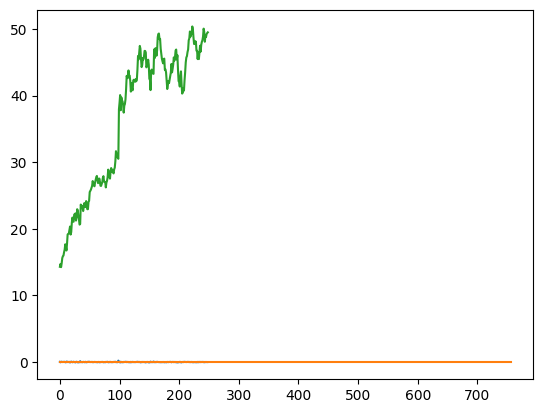

In [ ]:
print(log_ret.mean())


import matplotlib.pyplot as plt

# Create 3 rows, 1 column. sharex=True is often helpful for time-series data.
fig, axs = plt.subplots(3, 1, figsize=(8, 10), sharex=True)

# Plot each series on its assigned axis
axs[0].plot(log_ret)
axs[0].set_title('Log Returns')

axs[1].plot(mu_paths.mean(1))
axs[1].set_title('Mean of Mu Paths')

axs[2].plot(prices)
axs[2].set_title('Prices')

# Adjust layout to prevent title/label overlap
plt.tight_layout()
plt.show()


In [ ]:
# since mu is not dependant on V, and it pretty constant, just make it a normal variable
log_ret.mean()
log_ret.std()
mu_paths = log_ret.mean()+torch.randn(n_steps+1, n_paths)*log_ret.std()

np.float64(0.029475440459813207)

In [332]:
# ── 4. Compute mu(t) paths directly from V_paths ──────────────────────────────
# Shape: (n_steps+1, n_paths) — no re-simulation needed
mu_paths = alpha_mu + beta_mu * V_paths

# print(f"Average annualized return (mu) from data: {mu_paths}")
print(np.exp(mu))
print(prices[0]*np.exp(np.log(np.log(prices).mean())))
print(prices[0]*np.exp(log_ret.mean()*252))
print(prices[-1])
print(prices[0]*np.exp(mu))
print(np.exp(mu_paths.mean(dim=1).mean().numpy()*252))

print(prices[0]*np.exp(mu_paths.mean(dim=1).mean().numpy()*252))

[3.46098334]
[50.69296069]
[50.492813]
[49.49174881]
[49.49174881]
3.530989
[50.49282249]


In [333]:
# ── 5. ANN Policy ─────────────────────────────────────────────────────────────
class PolicyNet(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.net = torch.nn.Sequential(
            torch.nn.Linear(4, 128), torch.nn.Tanh(),
            torch.nn.Linear(128, 128), torch.nn.Tanh(),
            torch.nn.Linear(128, 1), torch.nn.Sigmoid()
        )
    def forward(self, x):
        return self.net(x)

policy    = PolicyNet()
optimizer = torch.optim.Adam(policy.parameters(), lr=1e-3)
gamma     = 3.0  # risk aversion

In [334]:
# simulate the W for analytic only

from numpy import ones_like


W_analytic_paths = torch.ones(n_steps+1, n_paths) # these are used for plotting the paths of W
W_analytic = torch.ones(n_paths)

for t in range(n_steps): 

        # V_paths/mu_paths/dW_S_all shape: (n_steps + 1, n_paths)
        # (5000 ele vector(paths), for each step)
        V_t  = V_paths[t]       # read from pre-simulated V tensor 
        mu_t = mu_paths[t]      # read from pre-computed mu tensor
        # mu_t = np.ones(n_paths)*mu
        # dW_S = dW_S_all[t]      # read pre-generated shock
        dW_S = torch.randn(n_paths) * (dt**0.5) # use different stochastic step every time
        

        # Analytic Merton pi
        with torch.no_grad():
            pi_analytic = ((mu_t - r) / (gamma * V_t)).clamp(0, 1)
            # 0.5*pi_analytic**2*V_t is the correction from Its's Lemma becuase we took the log of wealth/returns, not wealth itself
            W_analytic  = W_analytic * torch.exp(
                (r + pi_analytic*(mu_t - r) - 0.5*pi_analytic**2*V_t)*dt 
                + pi_analytic*torch.sqrt(V_t)*dW_S
            )
        W_analytic_paths[t+1]  = W_analytic


In [335]:
# print(mu_t)
# print(((mu_t - r) / (gamma * V_t)).clamp(0, 1))

# plt.plot(W_analytic_paths.mean(dim=1))
# plt.plot(mu_paths)
mu_paths

tensor([[0.0050, 0.0050, 0.0050,  ..., 0.0050, 0.0050, 0.0050],
        [0.0050, 0.0050, 0.0050,  ..., 0.0050, 0.0050, 0.0050],
        [0.0050, 0.0050, 0.0050,  ..., 0.0050, 0.0050, 0.0050],
        ...,
        [0.0050, 0.0050, 0.0050,  ..., 0.0050, 0.0050, 0.0050],
        [0.0050, 0.0050, 0.0050,  ..., 0.0050, 0.0050, 0.0050],
        [0.0050, 0.0050, 0.0050,  ..., 0.0050, 0.0050, 0.0050]])

In [336]:
# ── 6. Training Loop — reads from pre-simulated paths, no re-simulation ────────
best_loss    = float('inf')
patience     = 25   # stop if no improvement for 25 epochs
patience_ctr = 0

for epoch in range(2000):

    # n_steps = 3*252 = 756 trading days, but we have n_steps+1 values in our pre-simulated tensors (including t=0)
    # n_paths = 5000 Monte Carlo paths, all pre-simulated upfront
    W_analytic_paths = torch.ones(n_steps+1, n_paths) # these are used for plotting the paths of W
    W_analytic = torch.ones(n_paths)
    W_ann_paths = torch.ones(n_steps+1, n_paths) # these are used for plotting the paths of W
    W_ann = torch.ones(n_paths)
    pi_ann_paths = torch.zeros(n_steps+1, n_paths) # these are used for plotting the paths of pi
    pi_ann = torch.zeros(n_paths)
    

    for t in range(n_steps): 

        # V_paths/mu_paths/dW_S_all shape: (n_steps + 1, n_paths)
        # (5000 ele vector(paths), for each step)
        V_t  = V_paths[t]       # read from pre-simulated V tensor 
        mu_t = mu_paths[t]      # read from pre-computed mu tensor
        # dW_S = dW_S_all[t]      # read pre-generated shock
        dW_S = torch.randn(n_paths) * (dt**0.5)

        # Analytic Merton pi
        with torch.no_grad():
            pi_analytic = ((mu_t - r) / (gamma * V_t)).clamp(0, 1)
            # 0.5*pi_analytic**2*V_t is the correction from Its's Lemma becuase we took the log of wealth/returns, not wealth itself
            W_analytic  = W_analytic * torch.exp(
                (r + pi_analytic*(mu_t - r) - 0.5*pi_analytic**2*V_t)*dt 
                + pi_analytic*torch.sqrt(V_t)*dW_S
            )
        W_analytic_paths[t+1]  = W_analytic

        
        # use different stochastic step every epoch for ANN path (and different from analytic path),
        # to make it more robust to noise and not just overfit to the specific pre-generated shock
        dW_S = torch.randn(n_paths) * (dt**0.5) 
        # ANN pi
        state  = torch.stack([
            torch.full((n_paths,), t*dt),
            V_t,
            W_ann.detach(),
            mu_t
        ], dim=1)
        pi_ann = policy(state).squeeze()
        W_ann  = W_ann * torch.exp(
            (r + pi_ann*(mu_t - r) - 0.5*pi_ann**2*V_t)*dt
            + pi_ann*torch.sqrt(V_t)*dW_S
        )
        pi_ann_paths[t+1] = pi_ann
        W_ann_paths[t+1]  = W_ann

    # Loss over all Monte Carlo paths
    loss = -torch.mean(W_ann**(1 - gamma) / (1 - gamma))

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if epoch % 10 == 0:
        U_ann      = torch.mean(W_ann**(1-gamma)/(1-gamma)).item()
        U_analytic = torch.mean(W_analytic**(1-gamma)/(1-gamma)).item()
        print(f"Epoch {epoch:4d} | ANN: {U_ann:.4f} | Analytic: {U_analytic:.4f} | Loss: {loss.item():.4f}")


    # Early stopping check
    if loss.item() < best_loss - 1e-4:   # 1e-4 is minimum improvement threshold
        best_loss    = loss.item()
        patience_ctr = 0
        torch.save(policy.state_dict(), 'best_policy.pt')  # save best model
    else:
        patience_ctr += 1

    if patience_ctr >= patience:
        print(f"Early stopping at epoch {epoch}")
        break

# Reload best model
policy.load_state_dict(torch.load('best_policy.pt'))

Epoch    0 | ANN: -0.8360 | Analytic: -0.4997 | Loss: 0.8360
Epoch   10 | ANN: -0.5074 | Analytic: -0.4998 | Loss: 0.5074


KeyboardInterrupt: 

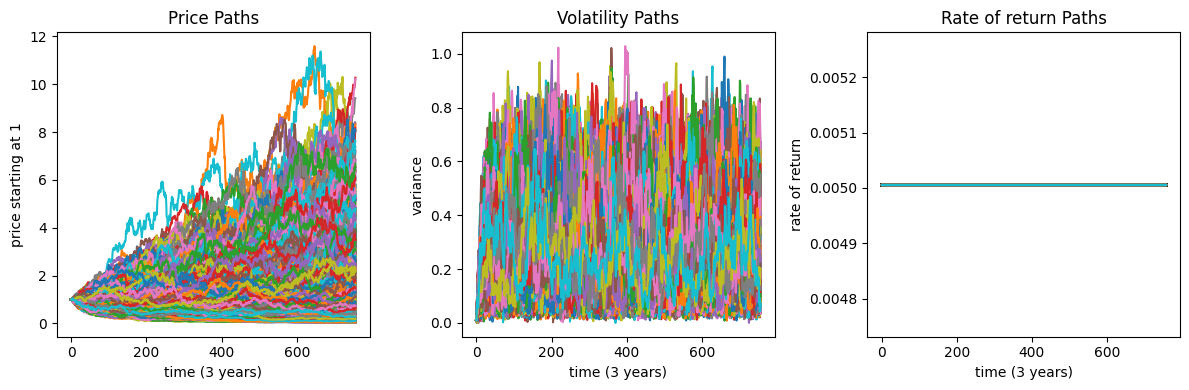

In [ ]:
import matplotlib.pyplot as plt

# ploting the price, volatility and rate of return
fig, axs = plt.subplots(1, 3, figsize=(12, 4))

# Access subplots by index
axs[0].plot(P_paths)
axs[0].set_title('Price Paths')
axs[0].set_xlabel('time (3 years)')
axs[0].set_ylabel('price starting at 1')

axs[1].plot(V_paths)
axs[1].set_title('Volatility Paths')
axs[1].set_xlabel('time (3 years)')
axs[1].set_ylabel('variance')

axs[2].plot(mu_paths, label='rate of return')
axs[2].set_title('Rate of return Paths')
axs[2].set_xlabel('time (3 years)')
axs[2].set_ylabel('rate of return')

plt.tight_layout() # Adjust spacing automatically
plt.show()

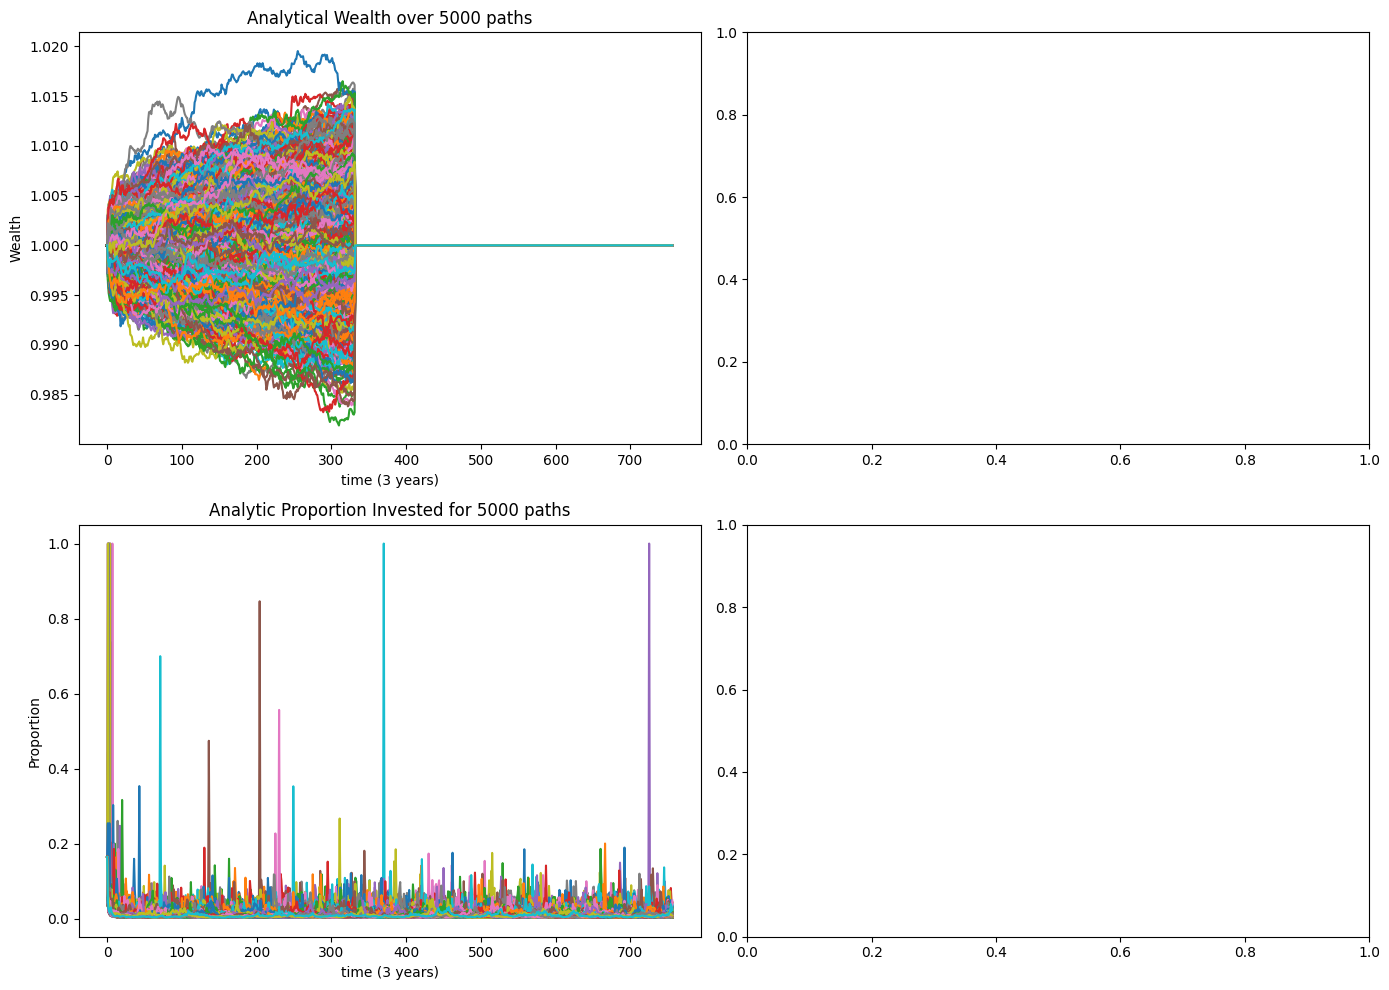

In [ ]:
import matplotlib.pyplot as plt

# Changed to 2x2 grid
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(14, 10))

# --- Row 1: Wealth Paths ---
ax1.plot(W_analytic_paths.detach())
ax1.set_xlabel('time (3 years)')
ax1.set_ylabel('Wealth')
ax1.set_title('Analytical Wealth over 5000 paths')

# ax2.plot(W_ann_paths.detach())
# ax2.set_xlabel('time (3 years)')
# ax2.set_ylabel('Wealth')
# ax2.set_title('ANN Wealth over 5000 paths')

# --- Row 2: Proportion Invested ---
pi_ANA = ((mu_paths - r) / (gamma * V_paths)).clamp(0, 1)
# pi_ANA = ((mu_t - r) / (gamma * V_paths)).clamp(0, 1)

ax3.plot(pi_ANA.detach() if hasattr(pi_ANA, 'detach') else pi_ANA)
ax3.set_xlabel('time (3 years)')
ax3.set_ylabel('Proportion')
ax3.set_title('Analytic Proportion Invested for 5000 paths')

# ax4.plot(pi_ann_paths.detach())
# ax4.set_xlabel('time (3 years)')
# ax4.set_ylabel('Proportion')
# ax4.set_title('ANN Proportion Invested  for 5000 paths')

plt.tight_layout()
plt.show()

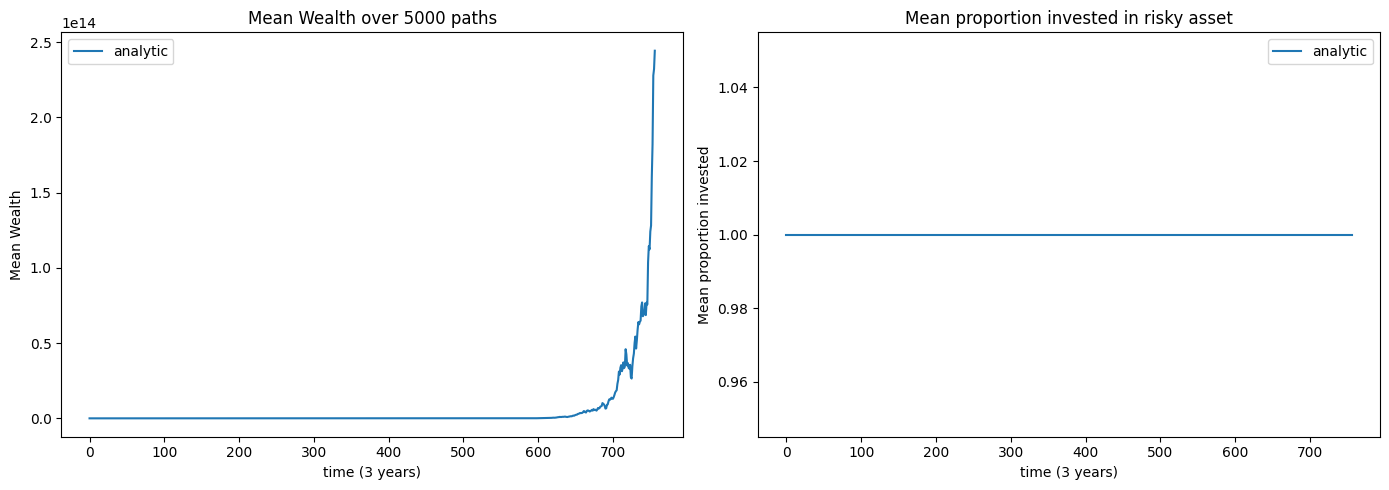

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# mean wealth plot
ax1.plot(W_analytic_paths.mean(dim=1), label='analytic')
# ax1.plot(W_ann_paths.detach().mean(dim=1), label='ANN')
ax1.set_xlabel('time (3 years)')
ax1.set_ylabel('Mean Wealth')
ax1.set_title('Mean Wealth over 5000 paths')
ax1.legend()


pi_ANA = ((mu_paths - r) / (gamma * V_paths)).clamp(0, 1)
# pi_ANA = ((mu_t - r) / (gamma * V_paths)).clamp(0, 1)

# mean proportion invested plot
ax2.plot(pi_ANA.mean(dim=1), label='analytic')
# ax2.plot(pi_ann_paths.detach().mean(dim=1), label='ANN')
ax2.set_xlabel('time (3 years)')
ax2.set_ylabel('Mean proportion invested')
ax2.set_title('Mean proportion invested in risky asset')
ax2.legend()

plt.tight_layout()
plt.show()